In [1]:
# STEP 1: Import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

print("✅ All libraries imported!")

✅ All libraries imported!


In [2]:
# STEP 2: Load the dataset

df = pd.read_csv('student_performance.csv')

# How many rows and columns?
print("Shape (rows, columns):", df.shape)

Shape (rows, columns): (10000, 8)


In [3]:
# STEP 3: First and last 5 rows

print("\n=== FIRST 5 ROWS ===")
print(df.head())

print("\n=== LAST 5 ROWS ===")
print(df.tail())



=== FIRST 5 ROWS ===
   Gender  Hours Studied  Previous Scores Extracurricular Activities Tuition  \
0  Female              7               82                        Yes     Yes   
1  Female              4               51                         No     Yes   
2    Male              8               52                        Yes     Yes   
3  Female              5               75                         No     Yes   
4  Female              7               78                         No     Yes   

   Sleep Hours  Sample Question Papers Practiced  Performance Index  
0            8                                 1                 82  
1            4                                 7                 37  
2            5                                 0                 50  
3            4                                 1                 68  
4            4                                 6                 79  

=== LAST 5 ROWS ===
      Gender  Hours Studied  Previous Scores Extracurric

In [4]:
# STEP 4: Data types of each column
# ----------------------------------------------------------
print("\n=== DATA TYPES ===")
print(df.dtypes)
# object = text | int64 = whole number


=== DATA TYPES ===
Gender                              object
Hours Studied                        int64
Previous Scores                      int64
Extracurricular Activities          object
Tuition                             object
Sleep Hours                          int64
Sample Question Papers Practiced     int64
Performance Index                    int64
dtype: object


In [5]:
# STEP 5: Statistical summary (min, max, average, etc.)

print("\n=== STATISTICAL SUMMARY ===")
print(df.describe())


=== STATISTICAL SUMMARY ===
       Hours Studied  Previous Scores   Sleep Hours  \
count   10000.000000     10000.000000  10000.000000   
mean        4.992900        68.990000      6.531100   
std         2.589309        17.088051      1.692962   
min         1.000000        40.000000      4.000000   
25%         3.000000        54.000000      5.000000   
50%         5.000000        69.000000      7.000000   
75%         7.000000        84.000000      8.000000   
max         9.000000        98.000000      9.000000   

       Sample Question Papers Practiced  Performance Index  
count                      10000.000000       10000.000000  
mean                           4.588200          58.514800  
std                            2.866573          19.045494  
min                            0.000000          13.000000  
25%                            2.000000          44.000000  
50%                            5.000000          58.000000  
75%                            7.000000         

In [6]:
# STEP 6: Check for missing values

print("\n=== MISSING VALUES ===")
print(df.isnull().sum())
# All should be 0 — this dataset is perfectly clean!


=== MISSING VALUES ===
Gender                              0
Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Tuition                             0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64


In [7]:
# STEP 7: Check for duplicate rows

print("\n=== DUPLICATE ROWS ===")
print("Count:", df.duplicated().sum())


=== DUPLICATE ROWS ===
Count: 26


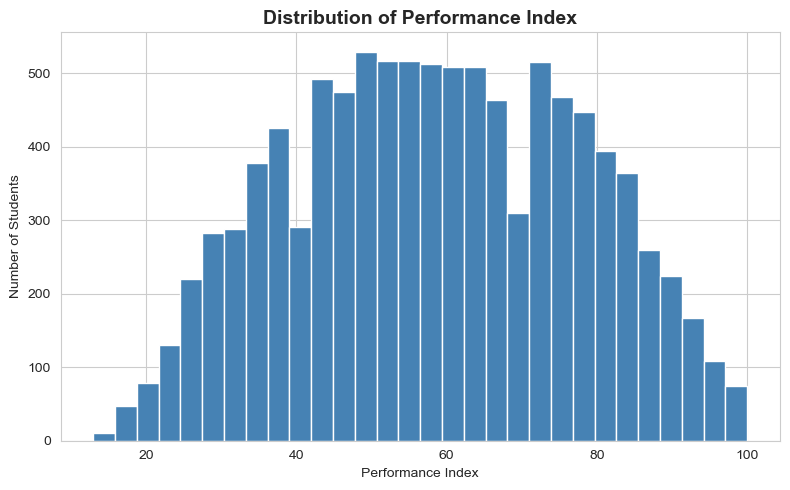

In [8]:
# UNIVARIATE ANALYSIS — one column at a time

# Chart 1: Distribution of Performance Index (our target)
plt.figure()
plt.hist(df['Performance Index'], bins=30, color='steelblue', edgecolor='white')
plt.title('Distribution of Performance Index', fontsize=14, fontweight='bold')
plt.xlabel('Performance Index')
plt.ylabel('Number of Students')
plt.tight_layout()
plt.show()
# OBSERVATION: Is the distribution spread evenly or skewed to one side?
# The Performance Index follows an approximately normal distribution, with most students scoring between 40 and 70, and very few at the extreme ends.

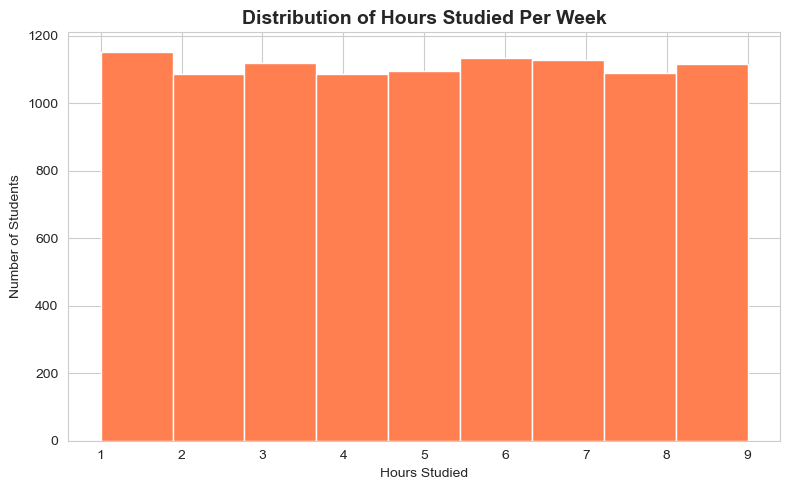

In [9]:
# Chart 2: Distribution of Hours Studied
plt.figure()
plt.hist(df['Hours Studied'], bins=9, color='coral', edgecolor='white')
plt.title('Distribution of Hours Studied Per Week', fontsize=14, fontweight='bold')
plt.xlabel('Hours Studied')
plt.ylabel('Number of Students')
plt.tight_layout()
plt.show()
# OBSERVATION: What is the most common number of study hours?
#Hours Studied is uniformly distributed, no single study duration is more common than others

C:\Users\SARTHAK\AppData\Local\Temp\ipykernel_3496\1927751643.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Gender', palette=['#FF9AA2', '#B5EAD7'])


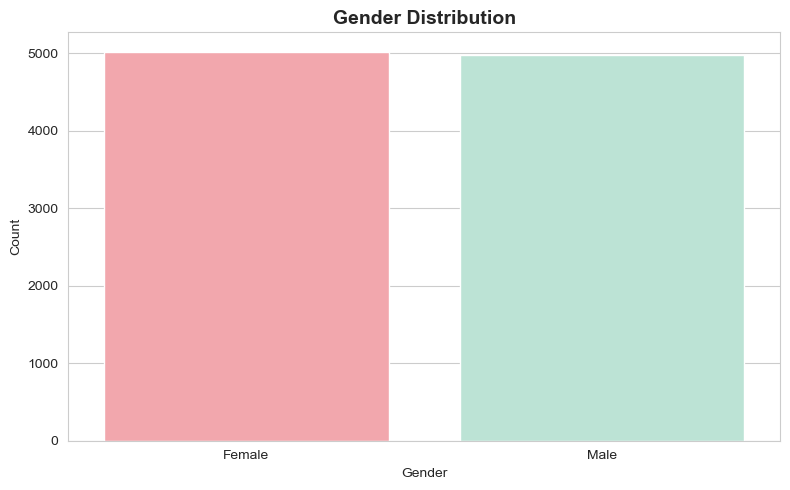

In [10]:
# Chart 3: Gender count
plt.figure()
sns.countplot(data=df, x='Gender', palette=['#FF9AA2', '#B5EAD7'])
plt.title('Gender Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.tight_layout()
plt.show()
# OBSERVATION: Is the dataset balanced between Male and Female?
#The dataset is almost perfectly balanced between Female (~50%) and Male (~50%) students, ensuring no gender bias in the model.

C:\Users\SARTHAK\AppData\Local\Temp\ipykernel_3496\3852525245.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Tuition', palette=['#FFD700', '#87CEEB'])


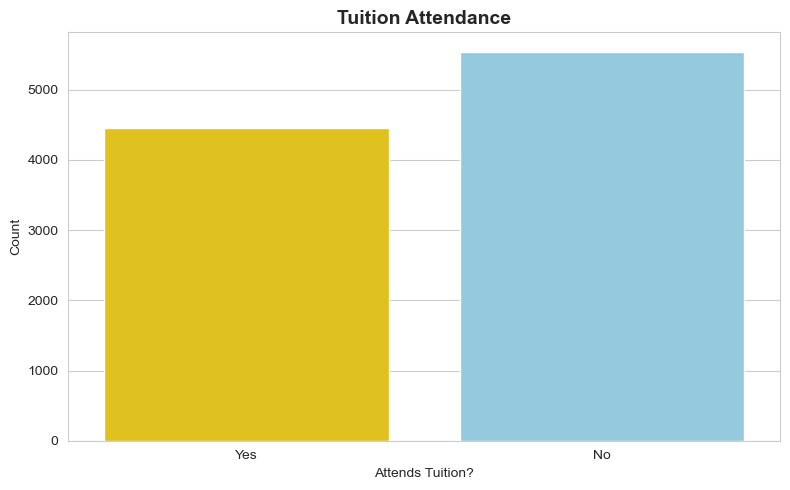

In [11]:
# Chart 4: Tuition count
plt.figure()
sns.countplot(data=df, x='Tuition', palette=['#FFD700', '#87CEEB'])
plt.title('Tuition Attendance', fontsize=14, fontweight='bold')
plt.xlabel('Attends Tuition?')
plt.ylabel('Count')
plt.tight_layout()
plt.show()
# OBSERVATION: More students attend tuition or skip it?
#Approximately 55% of students do not attend tuition, while 45% do. A reasonably balanced split with a slight majority skipping tuition.

C:\Users\SARTHAK\AppData\Local\Temp\ipykernel_3496\843862900.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Extracurricular Activities', palette=['#C7CEEA', '#FFDAC1'])


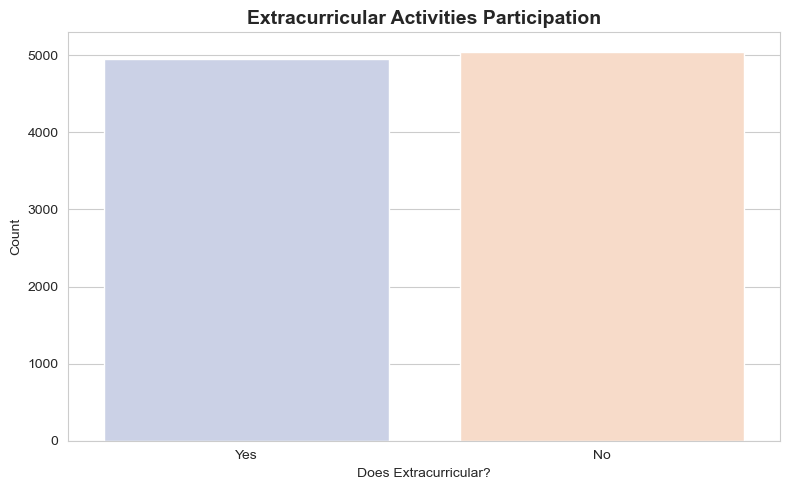

In [12]:
# Chart 5: Extracurricular count
plt.figure()
sns.countplot(data=df, x='Extracurricular Activities', palette=['#C7CEEA', '#FFDAC1'])
plt.title('Extracurricular Activities Participation', fontsize=14, fontweight='bold')
plt.xlabel('Does Extracurricular?')
plt.ylabel('Count')
plt.tight_layout()
plt.show()
# OBSERVATION: What proportion of students participate?
#Extracurricular participation is nearly equal (50/50)

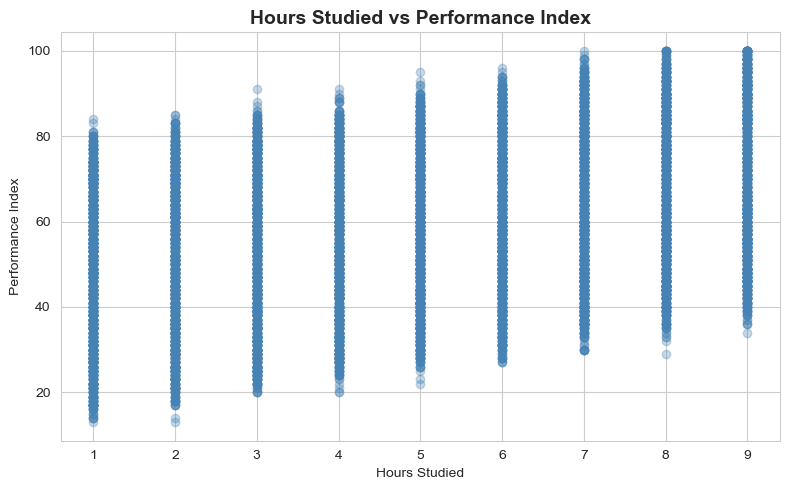

In [13]:
# ============================================================
# BIVARIATE ANALYSIS — each feature vs Performance Index
# ============================================================

# Chart 6: Hours Studied vs Performance Index
plt.figure()
plt.scatter(df['Hours Studied'], df['Performance Index'], alpha=0.3, color='steelblue')
plt.title('Hours Studied vs Performance Index', fontsize=14, fontweight='bold')
plt.xlabel('Hours Studied')
plt.ylabel('Performance Index')
plt.tight_layout()
plt.show()
# OBSERVATION: Is there a clear upward trend?
#There is a positive trend between hours studied and performance, but the wide spread within each column shows hours alone cannot fully predict the score, other factors matter too.

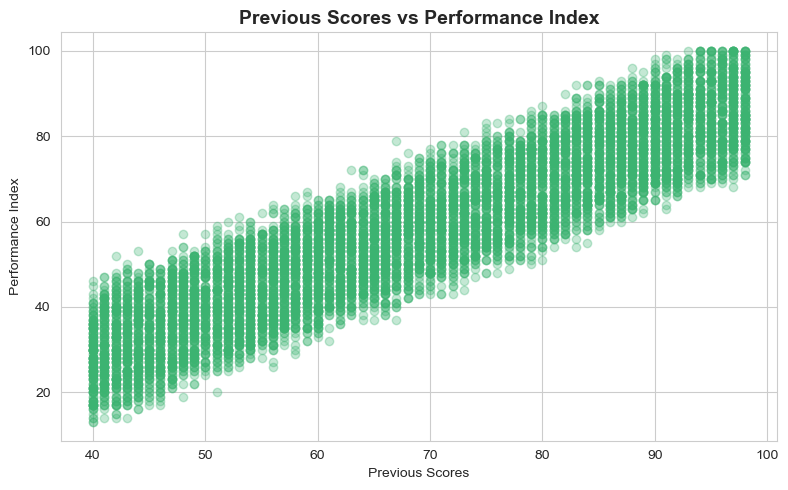

In [14]:
# Chart 7: Previous Scores vs Performance Index
plt.figure()
plt.scatter(df['Previous Scores'], df['Performance Index'], alpha=0.3, color='mediumseagreen')
plt.title('Previous Scores vs Performance Index', fontsize=14, fontweight='bold')
plt.xlabel('Previous Scores')
plt.ylabel('Performance Index')
plt.tight_layout()
plt.show()
# OBSERVATION: This shows a stronger trend than Hours Studied — past predicts future!
#Previous Scores shows the strongest and clearest positive trend with Performance Index. Students who did well before almost always do well again, confirming it as the most powerful predictor.

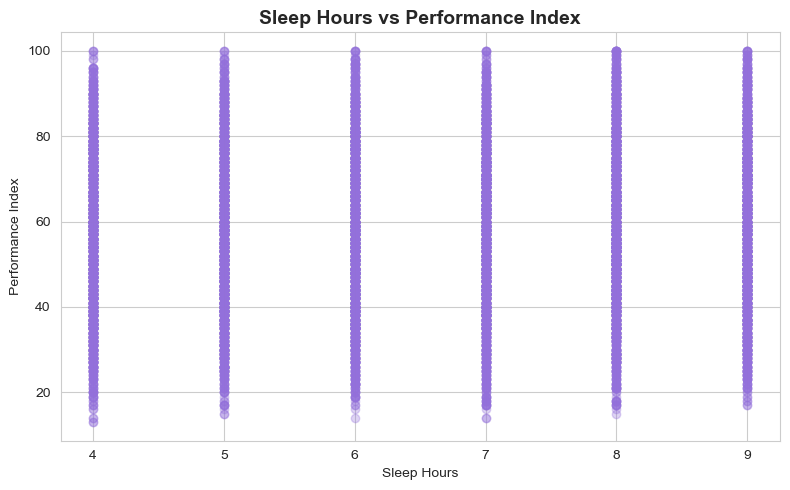

In [15]:
# Chart 8: Sleep Hours vs Performance Index
plt.figure()
plt.scatter(df['Sleep Hours'], df['Performance Index'], alpha=0.3, color='mediumpurple')
plt.title('Sleep Hours vs Performance Index', fontsize=14, fontweight='bold')
plt.xlabel('Sleep Hours')
plt.ylabel('Performance Index')
plt.tight_layout()
plt.show()
# OBSERVATION: Does more sleep clearly improve scores, or is the trend weak?
#Sleep Hours shows virtually no visible trend with Performance Index. The score range is identical across all sleep durations, suggesting sleep has minimal standalone impact.

C:\Users\SARTHAK\AppData\Local\Temp\ipykernel_3496\1894113936.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=gender_avg, x='Gender', y='Performance Index', palette=['#FF9AA2', '#B5EAD7'])


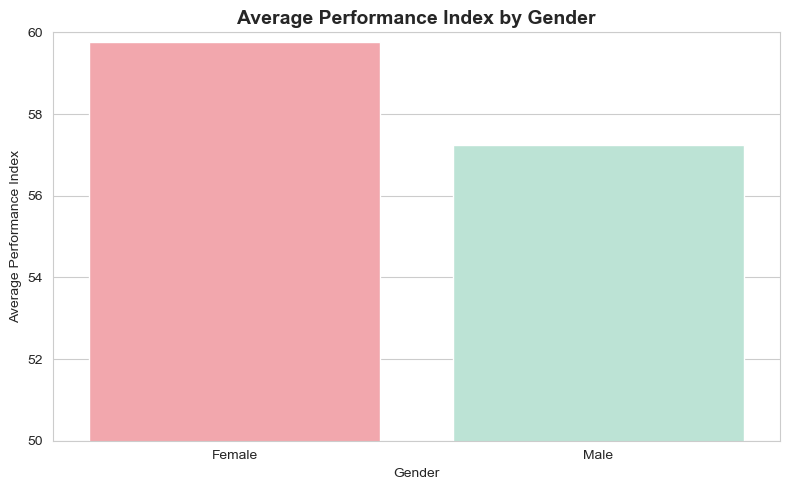

In [16]:
# Chart 9: Average score by Gender
plt.figure()
gender_avg = df.groupby('Gender')['Performance Index'].mean().reset_index()
sns.barplot(data=gender_avg, x='Gender', y='Performance Index', palette=['#FF9AA2', '#B5EAD7'])
plt.title('Average Performance Index by Gender', fontsize=14, fontweight='bold')
plt.ylabel('Average Performance Index')
plt.ylim(50, 60)
plt.tight_layout()
plt.show()
# OBSERVATION: Female students score slightly higher — by how many points?
#Female students score approximately 2.5 marks higher than Male students on average. A consistent but modest gender difference across the dataset.

C:\Users\SARTHAK\AppData\Local\Temp\ipykernel_3496\3320586889.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tuition_avg, x='Tuition', y='Performance Index', palette=['#FFD700', '#87CEEB'])


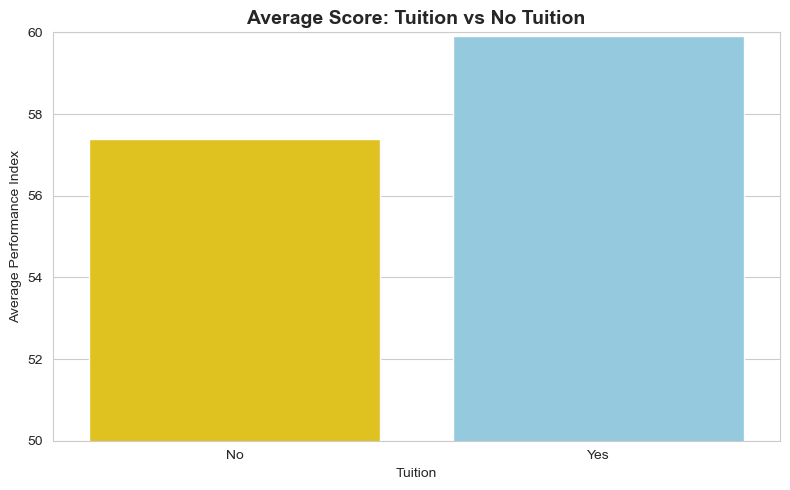

In [17]:
# Chart 10: Average score — Tuition vs No Tuition
plt.figure()
tuition_avg = df.groupby('Tuition')['Performance Index'].mean().reset_index()
sns.barplot(data=tuition_avg, x='Tuition', y='Performance Index', palette=['#FFD700', '#87CEEB'])
plt.title('Average Score: Tuition vs No Tuition', fontsize=14, fontweight='bold')
plt.ylabel('Average Performance Index')
plt.ylim(50, 60)
plt.tight_layout()
plt.show()
# OBSERVATION: Tuition students score higher — structured coaching has measurable impact!
#Students attending tuition score approximately 2–3 marks higher on average, confirming that structured external coaching provides a measurable performance advantage

C:\Users\SARTHAK\AppData\Local\Temp\ipykernel_3496\4052304773.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=extra_avg, x='Extracurricular Activities', y='Performance Index',


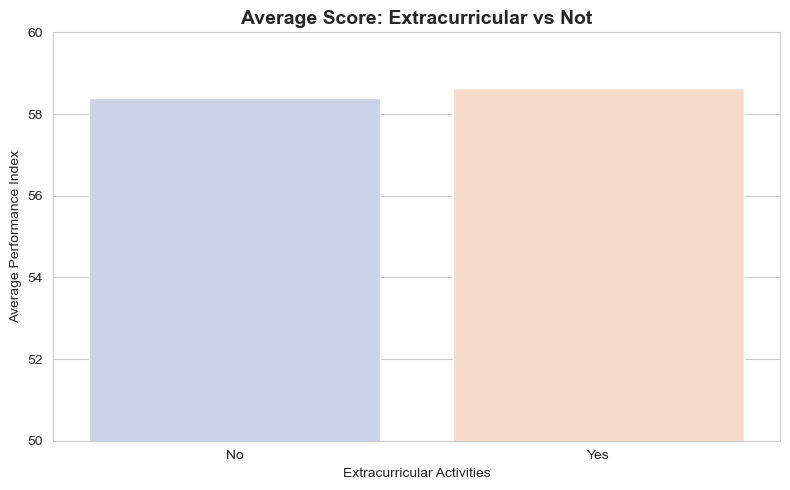

In [18]:
# Chart 11: Average score — Extracurricular vs Not
plt.figure()
extra_avg = df.groupby('Extracurricular Activities')['Performance Index'].mean().reset_index()
sns.barplot(data=extra_avg, x='Extracurricular Activities', y='Performance Index',
            palette=['#C7CEEA', '#FFDAC1'])
plt.title('Average Score: Extracurricular vs Not', fontsize=14, fontweight='bold')
plt.ylabel('Average Performance Index')
plt.ylim(50, 60)
plt.tight_layout()
plt.show()
# OBSERVATION: Do extracurricular activities help or slightly hurt scores?
#Extracurricular activities have almost no impact on average scores (difference < 0.5 marks), making it the weakest categorical predictor in the dataset.

C:\Users\SARTHAK\AppData\Local\Temp\ipykernel_3496\3172321566.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=papers_avg, x='Sample Question Papers Practiced',


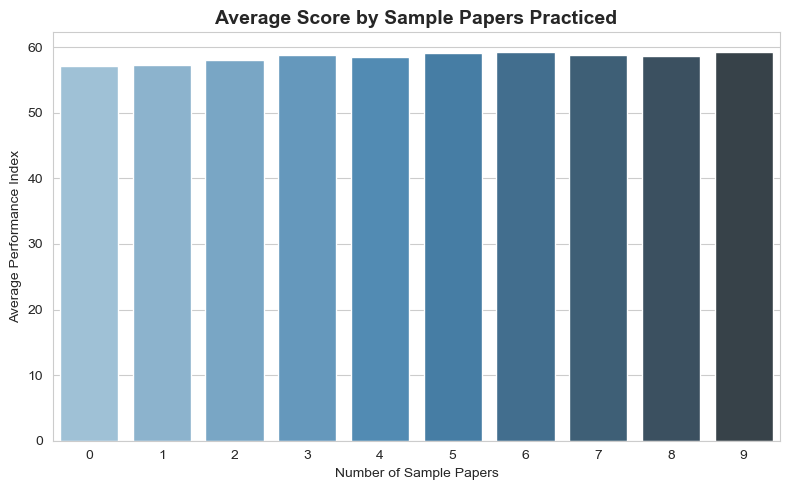

In [19]:
# Chart 12: Average score by Sample Papers Practiced
plt.figure()
papers_avg = df.groupby('Sample Question Papers Practiced')['Performance Index'].mean().reset_index()
sns.barplot(data=papers_avg, x='Sample Question Papers Practiced',
            y='Performance Index', palette='Blues_d')
plt.title('Average Score by Sample Papers Practiced', fontsize=14, fontweight='bold')
plt.xlabel('Number of Sample Papers')
plt.ylabel('Average Performance Index')
plt.tight_layout()
plt.show()
# OBSERVATION: More practice papers = higher score? Is the pattern consistent?
#Practicing more sample papers shows a very weak positive trend with scores. The improvement is marginal (~2 marks from 0 to 9 papers), suggesting it is a minor factor.

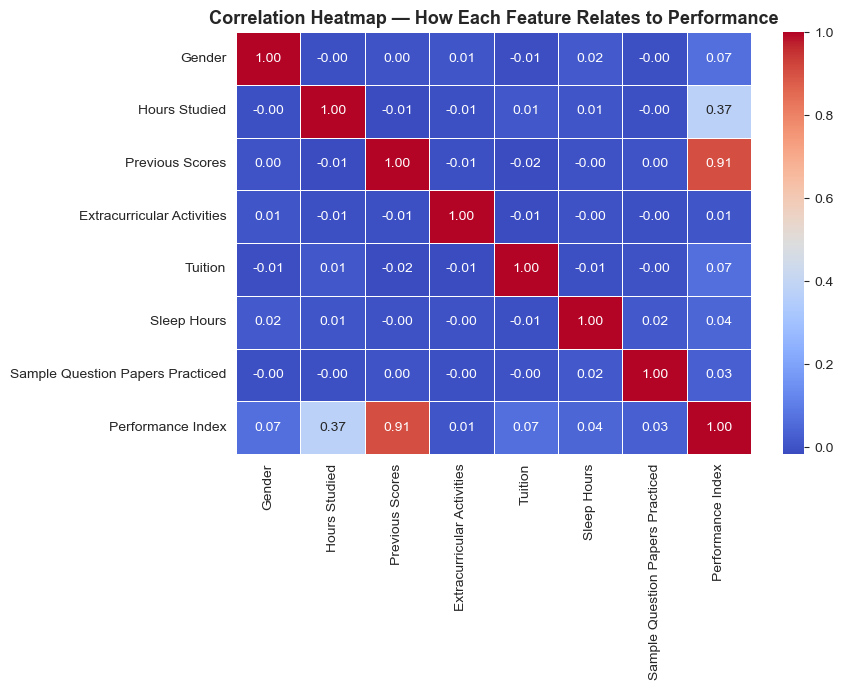

In [20]:
# CORRELATION HEATMAP
# ============================================================

# Temporarily encode text columns just for the heatmap
df_heatmap = df.copy()
df_heatmap['Gender'] = df_heatmap['Gender'].map({'Female': 1, 'Male': 0})
df_heatmap['Tuition'] = df_heatmap['Tuition'].map({'Yes': 1, 'No': 0})
df_heatmap['Extracurricular Activities'] = df_heatmap['Extracurricular Activities'].map({'Yes': 1, 'No': 0})

# Chart 13: Correlation Heatmap
plt.figure(figsize=(9, 7))
sns.heatmap(df_heatmap.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap — How Each Feature Relates to Performance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
# OBSERVATION — Previous Scores has the HIGHEST correlation with Performance Index (0.91), meaning past performance is by far the strongest predictor of future scores.
# OBSERVATION — Extracurricular Activities has the LOWEST correlation (0.01), which is surprising. It suggests participating in activities has almost zero direct impact on exam scores.

In [21]:
# PART 2 — DATA PREPROCESSING
# ============================================================

# STEP 1: Encode text columns to numbers (model only understands numbers)
df['Gender'] = df['Gender'].map({'Female': 1, 'Male': 0})
df['Tuition'] = df['Tuition'].map({'Yes': 1, 'No': 0})
df['Extracurricular Activities'] = df['Extracurricular Activities'].map({'Yes': 1, 'No': 0})

print("✅ Encoding done. First 5 rows:")
print(df.head())
# All three text columns now show 0s and 1s

✅ Encoding done. First 5 rows:
   Gender  Hours Studied  Previous Scores  Extracurricular Activities  \
0       1              7               82                           1   
1       1              4               51                           0   
2       0              8               52                           1   
3       1              5               75                           0   
4       1              7               78                           0   

   Tuition  Sleep Hours  Sample Question Papers Practiced  Performance Index  
0        1            8                                 1                 82  
1        1            4                                 7                 37  
2        1            5                                 0                 50  
3        1            4                                 1                 68  
4        1            4                                 6                 79  


In [22]:
# WHY Female=1 and Male=0?
# The choice doesn't matter for Linear Regression — the model learns the
# correct weight regardless. It would matter more in logistic regression.

In [23]:
# STEP 2: Define Features (X) and Target (y)
X = df.drop(columns=['Performance Index'])   # Everything EXCEPT the target
y = df['Performance Index']                   # ONLY the target column

print("\nX shape (features):", X.shape)   # Should be (10000, 7)
print("y shape (target)  :", y.shape)    # Should be (10000,)
print("\nFeature columns:", list(X.columns))


X shape (features): (10000, 7)
y shape (target)  : (10000,)

Feature columns: ['Gender', 'Hours Studied', 'Previous Scores', 'Extracurricular Activities', 'Tuition', 'Sleep Hours', 'Sample Question Papers Practiced']


In [24]:
# STEP 3: Train-Test Split (80% train, 20% test)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,    # Keep 20% hidden for testing
    random_state=42    # Same split every time you run this
)

print("\nX_train shape:", X_train.shape)   # Should be (8000, 7)
print("X_test  shape:", X_test.shape)     # Should be (2000, 7)
print("y_train shape:", y_train.shape)    # Should be (8000,)
print("y_test  shape:", y_test.shape)     # Should be (2000,)


X_train shape: (8000, 7)
X_test  shape: (2000, 7)
y_train shape: (8000,)
y_test  shape: (2000,)


In [25]:
# WHY keep 20% hidden?
# To test if the model TRULY learned the pattern, or just memorised the
# training data. Testing on unseen data = realistic real-world performance.

In [26]:
# PART 3 — MODEL BUILDING
from sklearn.linear_model import LinearRegression

# STEP 1: Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)   # This one line does all the learning!

print("✅ Model trained successfully!")


✅ Model trained successfully!


In [27]:
# STEP 2: What did the model learn?

# The base score before any features are considered
print(f"\nIntercept (base score): {model.intercept_:.2f}")

# How much each feature contributes to the predicted score
coefficients = pd.Series(model.coef_, index=X.columns)
print("\nCoefficients (sorted by impact):")
print(coefficients.sort_values(ascending=False).round(4))


Intercept (base score): -32.86

Coefficients (sorted by impact):
Tuition                             2.9934
Hours Studied                       2.8502
Gender                              2.4549
Previous Scores                     1.0187
Extracurricular Activities          0.6344
Sleep Hours                         0.4769
Sample Question Papers Practiced    0.1884
dtype: float64


In [28]:
# HIGHEST coefficient = most impactful feature
# Every 1 extra hour studied adds ~2.85 points to the predicted score!

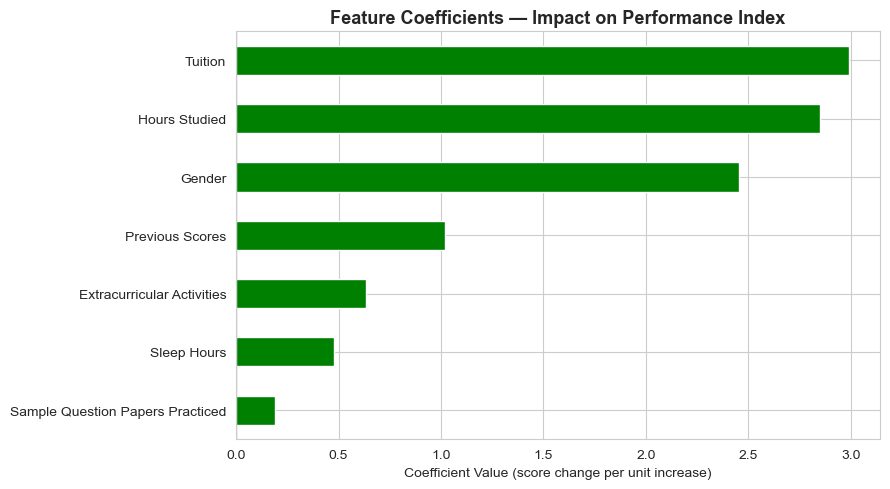

In [29]:
# Chart 14: Coefficients Bar Chart
plt.figure(figsize=(9, 5))
coefficients.sort_values().plot(
    kind='barh',
    color=['red' if x < 0 else 'green' for x in coefficients.sort_values()]
)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Feature Coefficients — Impact on Performance Index', fontsize=13, fontweight='bold')
plt.xlabel('Coefficient Value (score change per unit increase)')
plt.tight_layout()
plt.show()
# Green bar = helps score | Red bar = hurts score | Longer bar = stronger effect

In [30]:
# STEP 3: Make predictions on the test set
y_pred = model.predict(X_test)

# Show first 10 actual vs predicted side by side
comparison = pd.DataFrame({
    'Actual Score'   : y_test[:10].values,
    'Predicted Score': y_pred[:10].round(1),
    'Difference'     : (y_test[:10].values - y_pred[:10]).round(1)
})
print("\n=== First 10: Actual vs Predicted ===")
print(comparison.to_string(index=False))
# If Difference is within ±5 marks, the model is doing very well!


=== First 10: Actual vs Predicted ===
 Actual Score  Predicted Score  Difference
           64             64.2        -0.2
           52             53.7        -1.7
           47             49.4        -2.4
           61             59.7         1.3
           42             41.9         0.1
           90             91.4        -1.4
           58             57.1         0.9
           60             59.8         0.2
           76             76.2        -0.2
           67             66.3         0.7


In [31]:
# PART 4 — MODEL EVALUATION

from sklearn.metrics import mean_squared_error, r2_score

# STEP 1: Calculate metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f"📐 RMSE     : {rmse:.2f} marks")
print(f"📊 R² Score : {r2:.4f}  ({r2 * 100:.1f}% variance explained)")

📐 RMSE     : 2.11 marks
📊 R² Score : 0.9875  (98.8% variance explained)


In [32]:
# RMSE: On average, our prediction is off by ~2.1 marks. Excellent!
# R²  : Model explains ~98.75% of the variation in student scores.
# NOTE: R² this close to 1.0 may suggest the dataset is synthetic/simulated.
#       In real-world messy data, R² of 0.7–0.85 is considered very good.

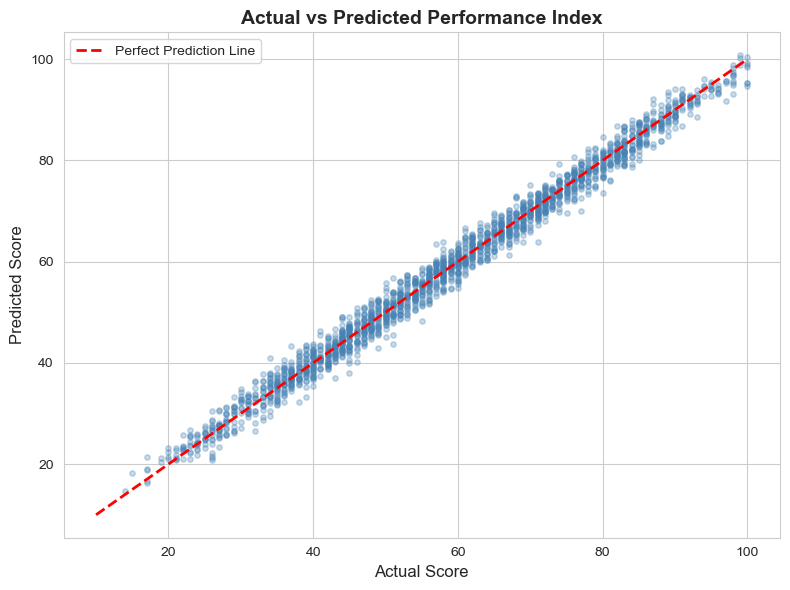

In [33]:
# STEP 2: Visualise — Actual vs Predicted Scatter Plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='steelblue', s=15)
plt.plot([10, 100], [10, 100], color='red', linestyle='--', linewidth=2,
         label='Perfect Prediction Line')
plt.xlabel('Actual Score', fontsize=12)
plt.ylabel('Predicted Score', fontsize=12)
plt.title('Actual vs Predicted Performance Index', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()
# If dots cluster tightly along the red diagonal line → model is accurate!

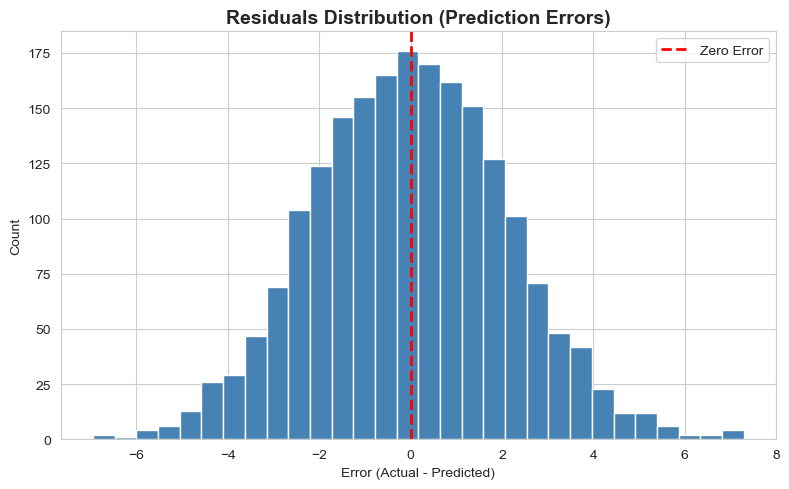

In [34]:
# STEP 3: Residuals Histogram
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=30, color='steelblue', edgecolor='white')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
plt.title('Residuals Distribution (Prediction Errors)', fontsize=14, fontweight='bold')
plt.xlabel('Error (Actual - Predicted)')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()
# If bell-shaped and centred around 0 → model is NOT systematically over/under predicting.

In [35]:
# PART 5 — LIVE PREDICTION FUNCTION
# ============================================================

def predict_score(gender, hours_studied, previous_scores,
                  extracurricular, tuition, sleep_hours, sample_papers):
    """
    Predicts a student's Performance Index based on their habits.

    Parameters:
        gender           : 'Female' or 'Male'
        hours_studied    : int, 1–9
        previous_scores  : int, 40–99
        extracurricular  : 'Yes' or 'No'
        tuition          : 'Yes' or 'No'
        sleep_hours      : int, 4–9
        sample_papers    : int, 0–9

    Returns:
        Predicted score (float)
    """
    # Step 1: Encode text inputs to numbers
    g = 1 if gender.lower() == 'female' else 0
    e = 1 if extracurricular.lower() == 'yes' else 0
    t = 1 if tuition.lower() == 'yes' else 0
    
    # Step 2: Build input row in same column order as training data
    student = pd.DataFrame(
        [[g, hours_studied, previous_scores, e, t, sleep_hours, sample_papers]],
        columns=X.columns
    )

    # Step 3: Predict
    score = model.predict(student)[0]

    print(f"\n📊 Predicted Performance Index: {round(score, 1)} / 100")

    if score >= 80:
        print("🌟 Excellent! This student is performing at a high level.")
    elif score >= 65:
        print("✅ Good performance. Some improvement is possible.")
    elif score >= 50:
        print("⚠️  Average. Needs more effort in study habits.")
    else:
        print("🔴 At-risk student. Immediate support recommended.")

    return round(score, 1)

print("✅ predict_score() function is ready!")

✅ predict_score() function is ready!


In [36]:
# ----------------------------------------------------------
# TEST 1: Student A — High achiever
# ----------------------------------------------------------
print("\n=== Student A: High Achiever ===")
predict_score('Female', 8, 85, 'Yes', 'Yes', 7, 5)


# ----------------------------------------------------------
# TEST 2: Student B — At-risk student
# ----------------------------------------------------------
print("\n=== Student B: At-Risk Student ===")
predict_score('Male', 2, 50, 'No', 'No', 5, 1)


# ----------------------------------------------------------
# TEST 3: Student C — Average student
# ----------------------------------------------------------
print("\n=== Student C: Average Student ===")
predict_score('Female', 5, 70, 'Yes', 'No', 6, 3)


# ----------------------------------------------------------
# TEST 4: Your own profile — fill in YOUR habits!
# ----------------------------------------------------------
print("\n=== MY Profile ===")
predict_score(
    gender          = 'Female',   # Change to 'Male' if needed
    hours_studied   = 5,          # Your weekly study hours
    previous_scores = 83,         # Your last exam score
    extracurricular = 'No',      # Do you do extracurriculars?
    tuition         = 'No',       # Do you attend tuition?
    sleep_hours     = 8,          # Average sleep hours
    sample_papers   = 3           # Sample papers practiced
)



=== Student A: High Achiever ===

📊 Predicted Performance Index: 86.9 / 100
🌟 Excellent! This student is performing at a high level.

=== Student B: At-Risk Student ===

📊 Predicted Performance Index: 26.4 / 100
🔴 At-risk student. Immediate support recommended.

=== Student C: Average Student ===

📊 Predicted Performance Index: 59.2 / 100
⚠️  Average. Needs more effort in study habits.

=== MY Profile ===

📊 Predicted Performance Index: 72.8 / 100
✅ Good performance. Some improvement is possible.


np.float64(72.8)

In [37]:
# EXPERIMENT: Change ONE variable at a time
# ----------------------------------------------------------
print("\n=== EXPERIMENT: Tuition YES vs NO (same student) ===")
s1 = predict_score('Female', 5, 70, 'No', 'Yes', 6, 3)
s2 = predict_score('Female', 5, 70, 'No', 'No',  6, 3)
print(f"\n💡 Tuition adds approximately {round(s1 - s2, 1)} points to the score!")

print("\n=== EXPERIMENT: Female vs Male (same student) ===")
s3 = predict_score('Female', 5, 70, 'No', 'No', 6, 3)
s4 = predict_score('Male',   5, 70, 'No', 'No', 6, 3)
print(f"\n💡 Gender difference: approximately {round(s3 - s4, 1)} points!")



=== EXPERIMENT: Tuition YES vs NO (same student) ===

📊 Predicted Performance Index: 61.6 / 100
⚠️  Average. Needs more effort in study habits.

📊 Predicted Performance Index: 58.6 / 100
⚠️  Average. Needs more effort in study habits.

💡 Tuition adds approximately 3.0 points to the score!

=== EXPERIMENT: Female vs Male (same student) ===

📊 Predicted Performance Index: 58.6 / 100
⚠️  Average. Needs more effort in study habits.

📊 Predicted Performance Index: 56.1 / 100
⚠️  Average. Needs more effort in study habits.

💡 Gender difference: approximately 2.5 points!


In [38]:
# Save predictions to CSV
# ----------------------------------------------------------
results = pd.DataFrame({
    'Actual Score'   : y_test.values,
    'Predicted Score': y_pred.round(1),
    'Difference'     : (y_test.values - y_pred).round(1)
})

results.to_csv('student_predictions.csv', index=False)
print("\n✅ student_predictions.csv saved!")
print("\nFirst 10 rows:")
print(results.head(10).to_string(index=False))

# What % of predictions are within ±5 marks?
within_5  = (abs(results['Difference']) <= 5).mean()  * 100
within_10 = (abs(results['Difference']) <= 10).mean() * 100

print(f"\n✅ {within_5:.1f}%  of predictions are within ±5  marks")
print(f"✅ {within_10:.1f}% of predictions are within ±10 marks")



✅ student_predictions.csv saved!

First 10 rows:
 Actual Score  Predicted Score  Difference
           64             64.2        -0.2
           52             53.7        -1.7
           47             49.4        -2.4
           61             59.7         1.3
           42             41.9         0.1
           90             91.4        -1.4
           58             57.1         0.9
           60             59.8         0.2
           76             76.2        -0.2
           67             66.3         0.7

✅ 98.2%  of predictions are within ±5  marks
✅ 100.0% of predictions are within ±10 marks
